# 01 — Data Collection: Pollen & Weather Data for France

**Objective:** Fetch daily pollen concentrations and meteorological covariates for 4 French cities (2022–2024) from the Open-Meteo APIs.

**Cities:**
| City | Climate | Latitude | Longitude |
|------|---------|----------|-----------|
| Paris | Oceanic / Continental | 48.8566 | 2.3522 |
| Marseille | Mediterranean | 43.2965 | 5.3698 |
| Strasbourg | Continental | 48.5734 | 7.7521 |
| Bordeaux | Oceanic | 44.8378 | −0.5792 |

**Data sources:**
- **Pollen:** Open-Meteo Air Quality API (CAMS / Copernicus) — hourly → resampled to daily mean
- **Weather:** Open-Meteo Historical Weather API (ERA5) — already daily

In [27]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import warnings
import numpy as np
import pandas as pd
import openmeteo_requests
import requests_cache
from retry_requests import retry

warnings.filterwarnings("ignore")
np.random.seed(42)

# Paths (relative to notebook location)
DATA_RAW = os.path.join("..", "Data", "raw")
DATA_PROC = os.path.join("..", "Data", "processed")
os.makedirs(DATA_RAW, exist_ok=True)
os.makedirs(DATA_PROC, exist_ok=True)

print("Setup complete.")

Setup complete.


In [28]:
# ── Configuration ────────────────────────────────────────────────────────────
CITIES = {
    "Paris":      {"lat": 48.8566, "lon": 2.3522,  "climate": "Oceanic/Continental"},
    "Marseille":  {"lat": 43.2965, "lon": 5.3698,  "climate": "Mediterranean"},
    "Strasbourg": {"lat": 48.5734, "lon": 7.7521,  "climate": "Continental"},
    "Bordeaux":   {"lat": 44.8378, "lon": -0.5792, "climate": "Oceanic"},
}

START_DATE = "2022-01-01"
END_DATE   = "2024-12-31"

POLLEN_SPECIES = [
    "birch_pollen", "alder_pollen", "grass_pollen",
    "olive_pollen", "mugwort_pollen", "ragweed_pollen",
]

WEATHER_VARS = [
    "temperature_2m_mean", "temperature_2m_max", "temperature_2m_min",
    "precipitation_sum", "windspeed_10m_max", "sunshine_duration",
    "relative_humidity_2m_mean",
]

print(f"Cities: {list(CITIES.keys())}")
print(f"Period: {START_DATE} → {END_DATE}")
print(f"Pollen species: {len(POLLEN_SPECIES)}, Weather variables: {len(WEATHER_VARS)}")

Cities: ['Paris', 'Marseille', 'Strasbourg', 'Bordeaux']
Period: 2022-01-01 → 2024-12-31
Pollen species: 6, Weather variables: 7


In [29]:
# ── Open-Meteo client with caching & retry ──────────────────────────────────
cache_session = requests_cache.CachedSession(
    os.path.join(DATA_RAW, ".cache"), expire_after=3600
)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
om = openmeteo_requests.Client(session=retry_session)

print("Open-Meteo client ready (cached + retry).")

Open-Meteo client ready (cached + retry).


## 1 — Pollen Data (Air Quality API)

The Open-Meteo Air Quality API provides **hourly** pollen concentrations (grains/m³) from the CAMS European model.  
We fetch hourly data per city, then resample to **daily mean** to align with weather data.

In [30]:
# ── Fetch hourly pollen data for all cities ──────────────────────────────────
def fetch_pollen(city_name, lat, lon):
    """Fetch hourly pollen data from Open-Meteo Air Quality API and resample to daily mean."""
    url = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": POLLEN_SPECIES,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "timezone": "Europe/Paris",
    }
    responses = om.weather_api(url, params=params)
    response = responses[0]

    # Build hourly DataFrame
    hourly = response.Hourly()
    hourly_data = {
        "datetime": pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left",
        )
    }
    for i, species in enumerate(POLLEN_SPECIES):
        hourly_data[species] = hourly.Variables(i).ValuesAsNumpy()

    df = pd.DataFrame(hourly_data)
    df["datetime"] = df["datetime"].dt.tz_convert("Europe/Paris")

    # Resample to daily mean
    df = df.set_index("datetime").resample("D").mean()
    df.index = df.index.date
    df.index.name = "date"
    df["city"] = city_name

    return df

# Fetch all cities
pollen_frames = []
for city, info in CITIES.items():
    print(f"Fetching pollen for {city}...")
    df = fetch_pollen(city, info["lat"], info["lon"])
    pollen_frames.append(df)
    print(f"  → {len(df)} days, {df.shape[1]-1} species")

pollen_raw = pd.concat(pollen_frames).reset_index()
pollen_raw["date"] = pd.to_datetime(pollen_raw["date"])
print(f"\nTotal pollen records: {len(pollen_raw)}")
pollen_raw.head()

Fetching pollen for Paris...
  → 1096 days, 6 species
Fetching pollen for Marseille...
  → 1096 days, 6 species
Fetching pollen for Strasbourg...
  → 1096 days, 6 species
Fetching pollen for Bordeaux...
  → 1096 days, 6 species

Total pollen records: 4384


,date,birch_pollen,alder_pollen,grass_pollen,olive_pollen,mugwort_pollen,ragweed_pollen,city
0,2022-01-01,NaN,0.0,NaN,0.0,NaN,NaN,Paris
1,2022-01-02,NaN,0.0,NaN,0.0,NaN,NaN,Paris
2,2022-01-03,NaN,0.0,NaN,0.0,NaN,NaN,Paris
3,2022-01-04,NaN,0.0,NaN,0.0,NaN,NaN,Paris
4,2022-01-05,NaN,0.0,NaN,0.0,NaN,NaN,Paris


## 2 — Weather Data (Historical Weather API)

ERA5 reanalysis data at daily resolution. Variables: mean/max/min temperature, precipitation, max wind speed, sunshine duration, and **relative humidity** (key driver of pollen dispersal — high humidity weighs down grains, reducing airborne concentration).

In [31]:
# ── Fetch daily weather data for all cities ──────────────────────────────────
def fetch_weather(city_name, lat, lon):
    """Fetch daily weather data from Open-Meteo Historical Weather API."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": WEATHER_VARS,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "timezone": "Europe/Paris",
    }
    responses = om.weather_api(url, params=params)
    response = responses[0]

    daily = response.Daily()
    daily_data = {
        "date": pd.date_range(
            start=pd.to_datetime(daily.Time(), unit="s", utc=True),
            end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=daily.Interval()),
            inclusive="left",
        )
    }
    for i, var in enumerate(WEATHER_VARS):
        daily_data[var] = daily.Variables(i).ValuesAsNumpy()

    df = pd.DataFrame(daily_data)
    df["date"] = df["date"].dt.tz_convert("Europe/Paris").dt.date
    df["date"] = pd.to_datetime(df["date"])
    df["city"] = city_name

    return df

# Fetch all cities
weather_frames = []
for city, info in CITIES.items():
    print(f"Fetching weather for {city}...")
    df = fetch_weather(city, info["lat"], info["lon"])
    weather_frames.append(df)
    print(f"  → {len(df)} days, {df.shape[1]-2} variables")

weather_raw = pd.concat(weather_frames, ignore_index=True)
print(f"\nTotal weather records: {len(weather_raw)}")
weather_raw.head()

Fetching weather for Paris...
  → 1096 days, 7 variables
Fetching weather for Marseille...
  → 1096 days, 7 variables
Fetching weather for Strasbourg...
  → 1096 days, 7 variables
Fetching weather for Bordeaux...
  → 1096 days, 7 variables

Total weather records: 4384


,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,sunshine_duration,relative_humidity_2m_mean,city
0,2022-01-01,9.112501,13.10,6.80,0.000000,15.790833,28245.619141,90.873924,Paris
1,2022-01-02,11.672916,13.85,8.55,1.200000,27.076691,20901.398438,78.943260,Paris
2,2022-01-03,11.043751,12.05,10.00,5.000000,30.319178,0.000000,85.953186,Paris
3,2022-01-04,8.629167,11.20,4.30,20.400003,27.748037,0.000000,88.742088,Paris
4,2022-01-05,2.987500,6.15,0.45,0.000000,20.447239,28800.000000,79.966309,Paris


## 3 — Save Raw Data

In [32]:
# ── Save raw CSVs ────────────────────────────────────────────────────────────
pollen_raw.to_csv(os.path.join(DATA_RAW, "pollen_raw.csv"), index=False)
weather_raw.to_csv(os.path.join(DATA_RAW, "weather_raw.csv"), index=False)

print(f"Saved: {DATA_RAW}/pollen_raw.csv  ({pollen_raw.shape})")
print(f"Saved: {DATA_RAW}/weather_raw.csv ({weather_raw.shape})")

Saved: ../Data/raw/pollen_raw.csv  ((4384, 8))
Saved: ../Data/raw/weather_raw.csv ((4384, 9))


## 4 — Data Quality Check

Quick sanity checks before merging:
- Date range coverage
- Missing values per city/variable
- Basic statistics

In [33]:
# ── Date range check ─────────────────────────────────────────────────────────
for name, df in [("Pollen", pollen_raw), ("Weather", weather_raw)]:
    print(f"=== {name} ===")
    for city in CITIES:
        subset = df[df["city"] == city]
        print(f"  {city}: {subset['date'].min().date()} → {subset['date'].max().date()} ({len(subset)} days)")
    print()

=== Pollen ===
  Paris: 2022-01-01 → 2024-12-31 (1096 days)
  Marseille: 2022-01-01 → 2024-12-31 (1096 days)
  Strasbourg: 2022-01-01 → 2024-12-31 (1096 days)
  Bordeaux: 2022-01-01 → 2024-12-31 (1096 days)

=== Weather ===
  Paris: 2022-01-01 → 2024-12-31 (1096 days)
  Marseille: 2022-01-01 → 2024-12-31 (1096 days)
  Strasbourg: 2022-01-01 → 2024-12-31 (1096 days)
  Bordeaux: 2022-01-01 → 2024-12-31 (1096 days)



In [34]:
# ── Missing values ───────────────────────────────────────────────────────────
print("=== Pollen — Missing values per city ===")
print(pollen_raw.groupby("city")[POLLEN_SPECIES].apply(lambda x: x.isna().sum()))
print()
print("=== Weather — Missing values per city ===")
print(weather_raw.groupby("city")[WEATHER_VARS].apply(lambda x: x.isna().sum()))

=== Pollen — Missing values per city ===
            birch_pollen  alder_pollen  grass_pollen  olive_pollen  \
city                                                                 
Bordeaux             378           322           316           322   
Marseille            378           322           316           322   
Paris                378           322           316           322   
Strasbourg           378           322           316           322   

            mugwort_pollen  ragweed_pollen  
city                                        
Bordeaux               378             378  
Marseille              378             378  
Paris                  378             378  
Strasbourg             378             378  

=== Weather — Missing values per city ===
            temperature_2m_mean  temperature_2m_max  temperature_2m_min  \
city                                                                      
Bordeaux                      0                   0                   0   


In [35]:
# ── Basic descriptive stats ──────────────────────────────────────────────────
print("=== Pollen — Summary ===")
display(pollen_raw[POLLEN_SPECIES].describe().round(2))
print()
print("=== Weather — Summary ===")
display(weather_raw[WEATHER_VARS].describe().round(2))

=== Pollen — Summary ===


,birch_pollen,alder_pollen,grass_pollen,olive_pollen,mugwort_pollen,ragweed_pollen
count,2872.00,3096.00,3120.00,3096.00,2872.00,2872.00
mean,3.96,0.39,5.81,0.13,2.01,0.34
std,16.47,2.43,11.28,0.88,5.20,1.38
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.95,0.00,0.03,0.00
75%,0.17,0.03,5.29,0.00,1.42,0.00
max,252.58,81.95,83.06,17.69,63.64,19.75



=== Weather — Summary ===


,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,sunshine_duration,relative_humidity_2m_mean
count,4384.00,4384.00,4384.00,4384.00,4384.00,4384.00,4384.00
mean,13.92,18.15,9.93,2.46,19.48,31255.96,75.03
std,6.77,7.54,6.28,5.21,8.27,15972.63,11.72
min,-7.78,-3.70,-11.00,0.00,4.50,0.00,32.86
25%,9.06,12.50,5.55,0.00,13.24,20818.44,68.46
50%,13.72,17.85,10.00,0.10,18.00,33522.56,76.66
75%,19.32,24.00,14.75,2.40,23.93,44421.30,83.74
max,30.62,40.45,24.20,64.90,56.62,57058.42,97.79


## 5 — Merge & Clean → Final Dataset

Merge pollen and weather on `(date, city)`. Handle missing values and unit conversions.

### Pollen NaN → 0: justification

The missing-value counts are **identical across all 4 cities** (e.g. birch: 378 NaN, alder: 322, grass: 316…). This is not random data loss — the CAMS European pollen model simply **does not produce forecasts for a given species outside its biological season** (e.g. birch pollen is not modelled in winter). Therefore, filling NaN with 0 is semantically correct: these dates correspond to periods when the species is biologically inactive and airborne concentration is effectively zero.

### Weather cleaning
- **`sunshine_duration`:** Converted from seconds → hours for interpretability.
- **Other variables:** Linear interpolation for small gaps (≤3 days), then forward/backward fill for any remaining.

In [36]:
# ── Merge pollen + weather ────────────────────────────────────────────────────
merged = pd.merge(pollen_raw, weather_raw, on=["date", "city"], how="inner")
print(f"Merged shape: {merged.shape}")
print(f"Date range: {merged['date'].min().date()} → {merged['date'].max().date()}")
print(f"Cities: {merged['city'].unique().tolist()}")

# ── Handle missing values ────────────────────────────────────────────────────
# Pollen: fill NaN with 0 (off-season = species not modelled by CAMS → zero concentration)
merged[POLLEN_SPECIES] = merged[POLLEN_SPECIES].fillna(0)

# Weather: interpolate then forward-fill per city
for city in CITIES:
    mask = merged["city"] == city
    merged.loc[mask, WEATHER_VARS] = (
        merged.loc[mask, WEATHER_VARS]
        .interpolate(method="linear", limit=3)
        .ffill()
        .bfill()
    )

# ── Unit conversion ──────────────────────────────────────────────────────────
# sunshine_duration: seconds → hours
merged["sunshine_duration"] = merged["sunshine_duration"] / 3600.0

# Verify no NaN remain
remaining_na = merged.isna().sum().sum()
print(f"\nRemaining NaN after cleaning: {remaining_na}")
print(f"sunshine_duration range: {merged['sunshine_duration'].min():.1f}h → {merged['sunshine_duration'].max():.1f}h")
merged.info()

Merged shape: (4384, 15)
Date range: 2022-01-01 → 2024-12-31
Cities: ['Paris', 'Marseille', 'Strasbourg', 'Bordeaux']

Remaining NaN after cleaning: 0
sunshine_duration range: 0.0h → 15.8h
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4384 entries, 0 to 4383
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       4384 non-null   datetime64[ns]
 1   birch_pollen               4384 non-null   float32       
 2   alder_pollen               4384 non-null   float32       
 3   grass_pollen               4384 non-null   float32       
 4   olive_pollen               4384 non-null   float32       
 5   mugwort_pollen             4384 non-null   float32       
 6   ragweed_pollen             4384 non-null   float32       
 7   city                       4384 non-null   object        
 8   temperature_2m_mean        4384 non-null   float32       
 9   temper

In [37]:
# ── Add metadata columns ─────────────────────────────────────────────────────
merged["climate"] = merged["city"].map({c: v["climate"] for c, v in CITIES.items()})
merged["month"] = merged["date"].dt.month
merged["year"] = merged["date"].dt.year
merged["day_of_year"] = merged["date"].dt.dayofyear

# Sort for time-series consistency
merged = merged.sort_values(["city", "date"]).reset_index(drop=True)

print(f"Final dataset: {merged.shape}")
merged.head()

Final dataset: (4384, 19)


,date,birch_pollen,alder_pollen,grass_pollen,olive_pollen,mugwort_pollen,ragweed_pollen,city,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,windspeed_10m_max,sunshine_duration,relative_humidity_2m_mean,climate,month,year,day_of_year
0,2022-01-01,0.0,0.0,0.0,0.0,0.0,0.0,Bordeaux,10.849999,18.50,6.55,0.0,12.069400,8.000000,82.588356,Oceanic,1,2022,1
1,2022-01-02,0.0,0.0,0.0,0.0,0.0,0.0,Bordeaux,11.918750,15.90,9.10,0.0,15.856356,8.000000,82.771149,Oceanic,1,2022,2
2,2022-01-03,0.0,0.0,0.0,0.0,0.0,0.0,Bordeaux,11.693749,15.95,8.30,0.0,15.141414,7.697502,85.337708,Oceanic,1,2022,3
3,2022-01-04,0.0,0.0,0.0,0.0,0.0,0.0,Bordeaux,12.216667,15.85,8.00,2.9,21.971800,3.665450,75.540512,Oceanic,1,2022,4
4,2022-01-05,0.0,0.0,0.0,0.0,0.0,0.0,Bordeaux,4.633333,7.65,1.00,0.2,14.799459,8.294201,84.047752,Oceanic,1,2022,5


## 6 — Seasonal Pollen Integral (SPIn)

### What is SPIn?

The **Seasonal Pollen Integral** (SPIn) is the standard metric in aerobiology to quantify the total pollen load for a given species during its active season (Galán et al., 2017). It is defined as:

$$\text{SPIn} = \sum_{d=d_{\text{start}}}^{d_{\text{end}}} C_d$$

where $C_d$ is the daily mean pollen concentration (grains/m³) and $[d_{\text{start}}, d_{\text{end}}]$ defines the pollen season.

### Season definition — Cumulative 5%-95% method

The pollen season boundaries are defined using the **cumulative percentage method**:
- **Season start** ($d_{\text{start}}$): first day when the cumulative sum reaches **5%** of the annual total
- **Season end** ($d_{\text{end}}$): first day when the cumulative sum reaches **95%** of the annual total

This method is preferred over fixed thresholds because:
1. It is **species-agnostic** — no need to calibrate a different threshold per species
2. It captures **90% of the annual pollen load** by construction
3. It is **robust to isolated off-season spikes** (which would trigger a fixed-threshold approach prematurely)

### Outputs computed

We compute three levels of granularity:

| Dataset | Granularity | Content |
|---------|-------------|---------|
| `spin_annual.csv` | 1 row per (city, species, year) | SPIn, season start/end/duration, peak concentration, peak date |
| `spin_monthly.csv` | 1 row per (city, species, year, month) | Monthly partial SPIn = sum of daily concentrations within each month |

Both will be useful downstream:
- **Annual SPIn** → cross-city and inter-annual comparison (research question)
- **Monthly SPIn** → intra-seasonal distribution, phenological shifts

In [38]:
# ── SPIn: Season detection + annual metrics ──────────────────────────────────

def compute_season_metrics(series, year_dates):
    """
    Compute SPIn and seasonal metrics for a single (city, species, year) group.

    Parameters
    ----------
    series : array-like — daily pollen concentrations for one year
    year_dates : array-like — corresponding dates

    Returns
    -------
    dict with: spin, season_start, season_end, season_duration_days,
               peak_concentration, peak_date
    """
    values = np.array(series, dtype=float)
    dates = np.array(year_dates)
    total = values.sum()

    # Edge case: no pollen at all this year for this species
    if total == 0:
        return {
            "spin": 0.0,
            "season_start": pd.NaT,
            "season_end": pd.NaT,
            "season_duration_days": 0,
            "peak_concentration": 0.0,
            "peak_date": pd.NaT,
        }

    # Cumulative percentage
    cumsum = np.cumsum(values)
    cum_pct = cumsum / total

    # Season start: first day >= 5% of annual total
    start_idx = np.searchsorted(cum_pct, 0.05)
    # Season end: first day >= 95% of annual total
    end_idx = np.searchsorted(cum_pct, 0.95)

    season_start = dates[start_idx]
    season_end = dates[end_idx]

    # SPIn = sum of daily concentrations within the season window
    season_values = values[start_idx : end_idx + 1]
    spin = float(season_values.sum())

    # Peak within season
    peak_idx_in_season = np.argmax(season_values)
    peak_concentration = float(season_values[peak_idx_in_season])
    peak_date = dates[start_idx + peak_idx_in_season]

    duration = (pd.Timestamp(season_end) - pd.Timestamp(season_start)).days + 1

    return {
        "spin": round(spin, 2),
        "season_start": season_start,
        "season_end": season_end,
        "season_duration_days": duration,
        "peak_concentration": round(peak_concentration, 2),
        "peak_date": peak_date,
    }


# ── Compute for all (city, species, year) combinations ───────────────────────
spin_records = []

for city in CITIES:
    city_df = merged[merged["city"] == city].sort_values("date")
    for year in sorted(merged["year"].unique()):
        year_df = city_df[city_df["year"] == year]
        for species in POLLEN_SPECIES:
            metrics = compute_season_metrics(year_df[species].values, year_df["date"].values)
            spin_records.append({
                "city": city,
                "species": species.replace("_pollen", ""),
                "year": year,
                **metrics,
            })

spin_annual = pd.DataFrame(spin_records)
print(f"SPIn annual table: {spin_annual.shape}")
print(f"Non-zero seasons: {(spin_annual['spin'] > 0).sum()} / {len(spin_annual)}")
display(spin_annual.head(12))

SPIn annual table: (72, 9)
Non-zero seasons: 72 / 72


,city,species,year,spin,season_start,season_end,season_duration_days,peak_concentration,peak_date
0,Paris,birch,2022,1597.87,2022-03-26,2022-04-26,32,145.48,2022-04-12
1,Paris,alder,2022,18.94,2022-02-13,2022-04-12,59,1.35,2022-03-02
2,Paris,grass,2022,1390.27,2022-05-17,2022-08-03,79,52.40,2022-06-19
3,Paris,olive,2022,10.63,2022-05-16,2022-06-05,21,2.62,2022-05-16
4,Paris,mugwort,2022,1428.97,2022-07-03,2022-09-19,79,63.64,2022-07-28
5,Paris,ragweed,2022,59.08,2022-08-17,2022-09-15,30,9.62,2022-09-05
6,Paris,birch,2023,1096.17,2023-03-28,2023-04-30,34,138.28,2023-04-18
7,Paris,alder,2023,101.44,2023-02-01,2023-03-29,57,17.50,2023-02-14
8,Paris,grass,2023,1329.85,2023-05-22,2023-07-23,63,55.58,2023-06-09
9,Paris,olive,2023,2.22,2023-05-04,2023-06-20,48,2.05,2023-05-04


In [39]:
# ── SPIn: Monthly partial integral ────────────────────────────────────────────
# Monthly SPIn = sum of daily concentrations within each calendar month.
# This is NOT restricted to the season window — it captures the full annual
# distribution so we can observe when pollen load accumulates month by month.

spin_monthly_records = []

for city in CITIES:
    city_df = merged[merged["city"] == city].sort_values("date")
    for year in sorted(merged["year"].unique()):
        year_df = city_df[city_df["year"] == year]
        for species in POLLEN_SPECIES:
            species_name = species.replace("_pollen", "")
            monthly_sums = year_df.groupby("month")[species].sum()
            for month, monthly_spin in monthly_sums.items():
                spin_monthly_records.append({
                    "city": city,
                    "species": species_name,
                    "year": year,
                    "month": month,
                    "spin_monthly": round(float(monthly_spin), 2),
                })

spin_monthly = pd.DataFrame(spin_monthly_records)
print(f"SPIn monthly table: {spin_monthly.shape}")
display(spin_monthly[spin_monthly["spin_monthly"] > 0].head(10))

SPIn monthly table: (864, 5)


,city,species,year,month,spin_monthly
2,Paris,birch,2022,3,544.62
3,Paris,birch,2022,4,1192.00
4,Paris,birch,2022,5,10.42
5,Paris,birch,2022,6,1.42
12,Paris,alder,2022,1,0.12
13,Paris,alder,2022,2,7.25
14,Paris,alder,2022,3,10.79
15,Paris,alder,2022,4,1.77
16,Paris,alder,2022,5,0.32
26,Paris,grass,2022,3,0.16


In [40]:
# ── Quick validation: SPIn annual vs monthly consistency ──────────────────────
# The annual SPIn (computed on the 5%-95% season window) should be ≤ the sum of
# all monthly SPIn (which covers the full year). Let's verify.

check = spin_monthly.groupby(["city", "species", "year"])["spin_monthly"].sum().reset_index()
check.columns = ["city", "species", "year", "full_year_sum"]
check = check.merge(spin_annual[["city", "species", "year", "spin"]], on=["city", "species", "year"])
check["ratio_season_to_full"] = (check["spin"] / check["full_year_sum"].replace(0, np.nan)).round(3)

print("SPIn season (5%-95%) vs full year sum — should be ~0.90 by construction:")
print(f"  Mean ratio: {check['ratio_season_to_full'].mean():.3f}")
print(f"  Min ratio:  {check['ratio_season_to_full'].min():.3f}")
print(f"  Max ratio:  {check['ratio_season_to_full'].max():.3f}")

SPIn season (5%-95%) vs full year sum — should be ~0.90 by construction:
  Mean ratio: 0.921
  Min ratio:  0.901
  Max ratio:  0.993


## 7 — Save Processed Data

We save four types of datasets:
- **Long format** (`pollen_weather_merged.csv`): one row per (date, city) — daily time series
- **Per-city CSVs** (`pollen_weather_{city}.csv`): one file per city — for individual TS modelling
- **SPIn annual** (`spin_annual.csv`): one row per (city, species, year) — seasonal metrics
- **SPIn monthly** (`spin_monthly.csv`): one row per (city, species, year, month) — monthly partial integral

In [41]:
# ── Save processed data ──────────────────────────────────────────────────────
# Full merged dataset
merged_path = os.path.join(DATA_PROC, "pollen_weather_merged.csv")
merged.to_csv(merged_path, index=False)
print(f"Saved: {merged_path} ({merged.shape})")

# Per-city files
for city in CITIES:
    city_df = merged[merged["city"] == city].copy()
    city_path = os.path.join(DATA_PROC, f"pollen_weather_{city.lower()}.csv")
    city_df.to_csv(city_path, index=False)
    print(f"Saved: {city_path} ({city_df.shape})")

# SPIn datasets
spin_annual_path = os.path.join(DATA_PROC, "spin_annual.csv")
spin_annual.to_csv(spin_annual_path, index=False)
print(f"Saved: {spin_annual_path} ({spin_annual.shape})")

spin_monthly_path = os.path.join(DATA_PROC, "spin_monthly.csv")
spin_monthly.to_csv(spin_monthly_path, index=False)
print(f"Saved: {spin_monthly_path} ({spin_monthly.shape})")

Saved: ../Data/processed/pollen_weather_merged.csv ((4384, 19))
Saved: ../Data/processed/pollen_weather_paris.csv ((1096, 19))
Saved: ../Data/processed/pollen_weather_marseille.csv ((1096, 19))
Saved: ../Data/processed/pollen_weather_strasbourg.csv ((1096, 19))
Saved: ../Data/processed/pollen_weather_bordeaux.csv ((1096, 19))
Saved: ../Data/processed/spin_annual.csv ((72, 9))
Saved: ../Data/processed/spin_monthly.csv ((864, 5))


## 8 — Quick Visual Sanity Check

Plot one pollen species (grass) across all 4 cities to confirm data looks reasonable.

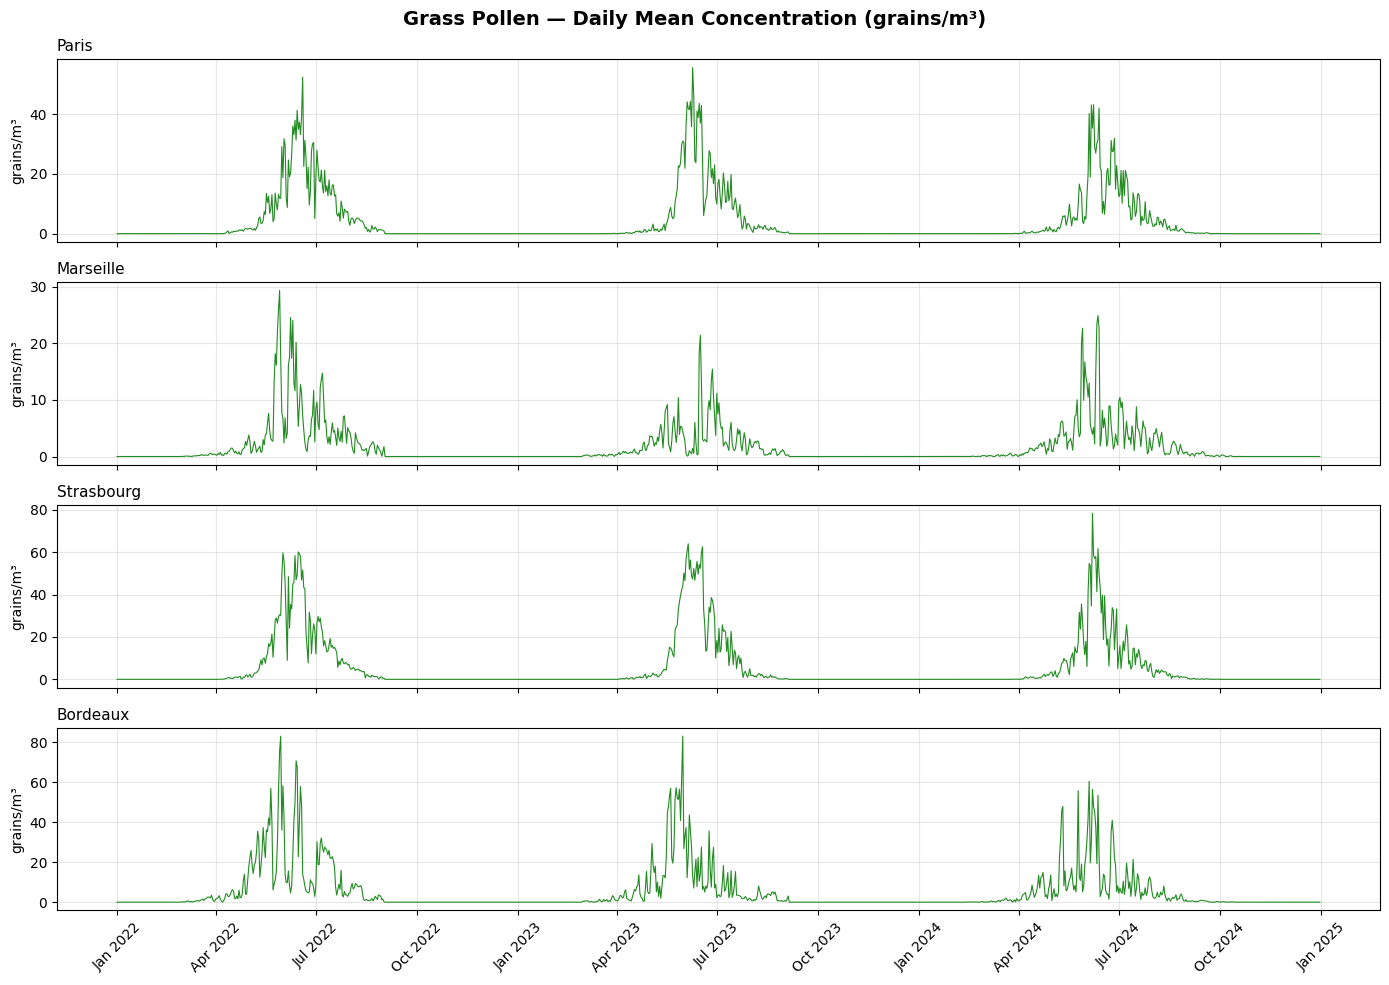

Sanity check plot saved.


In [43]:
# ── Quick sanity plot ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Grass Pollen — Daily Mean Concentration (grains/m³)", fontsize=14, fontweight="bold")

for ax, city in zip(axes, CITIES):
    city_df = merged[merged["city"] == city]
    ax.plot(city_df["date"], city_df["grass_pollen"], linewidth=0.8, color="forestgreen")
    ax.set_ylabel("grains/m³")
    ax.set_title(city, fontsize=11, loc="left")
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(os.path.join("..", "figures", "00_grass_pollen_sanity_check.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Sanity check plot saved.")

---

## Summary

| Item | Detail |
|------|--------|
| **Cities** | Paris, Marseille, Strasbourg, Bordeaux |
| **Period** | 2022-01-01 → 2024-12-31 (1096 days/city) |
| **Pollen species** | birch, alder, grass, olive, mugwort, ragweed |
| **Weather variables** | temp mean/max/min, precipitation, wind speed, sunshine (h), relative humidity |
| **SPIn method** | Cumulative 5%–95% season definition (Galán et al., 2017) |
| **Raw files** | `Data/raw/pollen_raw.csv`, `Data/raw/weather_raw.csv` |
| **Processed files** | `pollen_weather_merged.csv`, per-city CSVs, `spin_annual.csv`, `spin_monthly.csv` |
| **Cleaning** | Pollen NaN → 0 (off-season, structural), sunshine sec→h, weather interpolated |

**Next:** `02_eda.ipynb` — Exploratory Data Analysis